Task 3 :  Clustering Analysis – Customer Segmentation

Loading Dataset
Shape: (200, 5)

 First 5 rows:
    CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

Missing values:
 CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Duplicates: 0

Data types:
 CustomerID                int64
Gender                      str
Age                       int64
Annual Income (k$)        int64
Spending Score (1-100)    int64
dtype: object

 Summary statistics: 
        CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000    

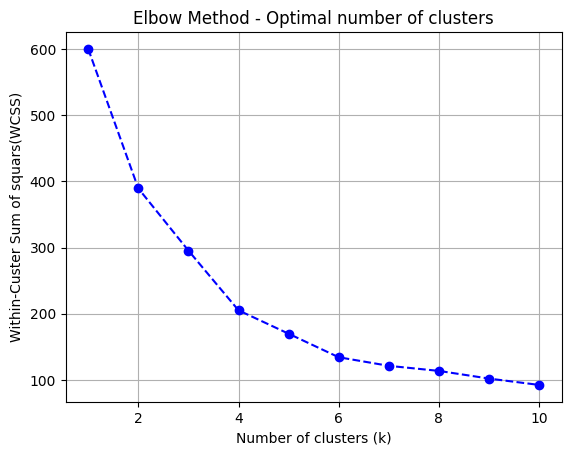

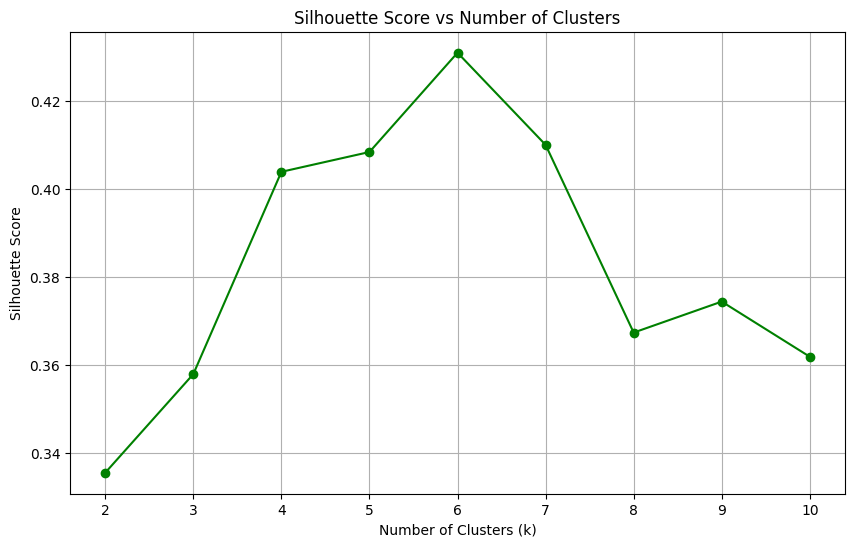

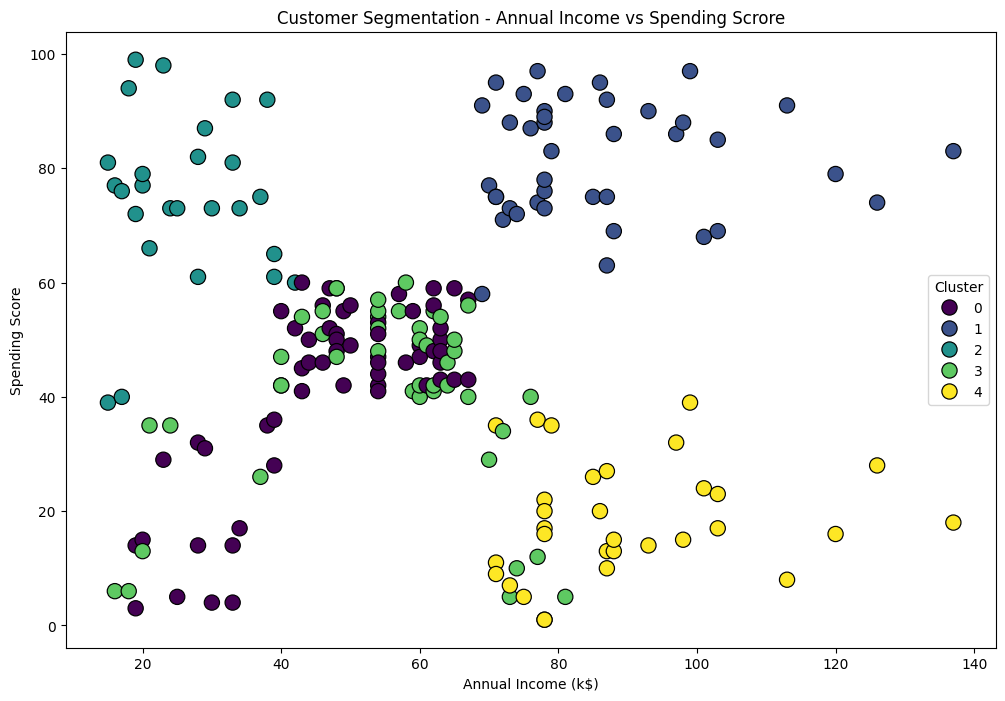

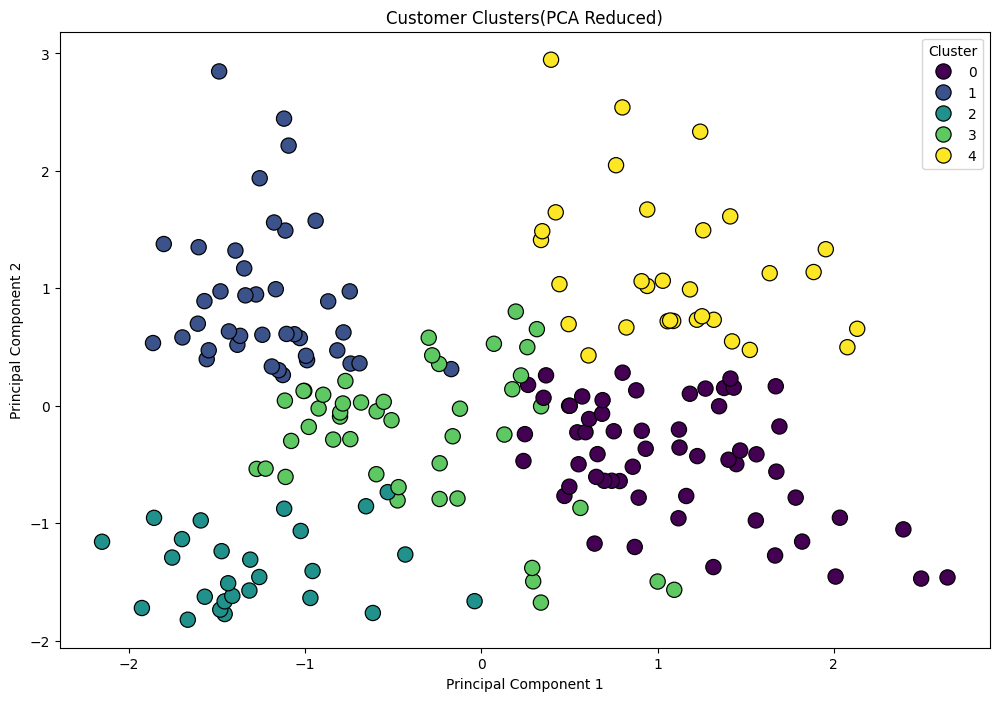

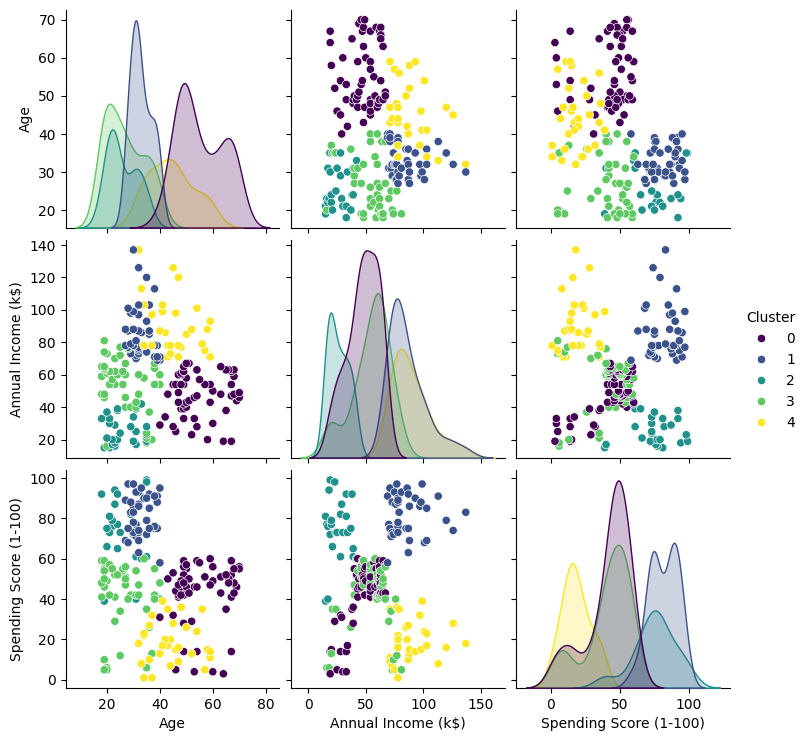


SUCCESS! Clustered dataset saved as 'clustered_customer_data.csv'

Cluster Distribution:
 Cluster
0    58
1    40
2    26
3    45
4    31
Name: count, dtype: int64

Mean values per cluster:
           Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                   
0        55.28               47.62                   41.71
1        32.88               86.10                   81.53
2        25.77               26.12                   74.85
3        26.73               54.31                   40.91
4        44.39               89.77                   18.48


In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

## Load the Dataset
print("Loading Dataset")
df = pd.read_csv('customer_data.csv')

print(f"Shape: {df.shape}")
print("\n First 5 rows:\n",df.head())
print("\nMissing values:\n",df.isnull().sum())
print("\nDuplicates:",df.duplicated().sum())
print("\nData types:\n",df.dtypes)
print("\n Summary statistics: \n",df.describe())

#Data Preprocessing
print("\n Preprocessing")
features = ['Age','Annual Income (k$)','Spending Score (1-100)']
x = df[features]

# Standardize(very imortant for K-Means)
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)
print("Data standardized successfully!")

#Clustering
print("finding optimal clusters (Elbow method)")
wcss = []
for i in range(1,11):
    kmeans = KMeans(n_clusters=i,init='k-means++',random_state=42)
    kmeans.fit(x_scaled)
    wcss.append(kmeans.inertia_)

#Plot Elbow method
plt.Figure(figsize=(10,6))
plt.plot(range(1,11),wcss,marker='o',linestyle='--',color='b')
plt.title("Elbow Method - Optimal number of clusters")
plt.xlabel('Number of clusters (k)')
plt.ylabel('Within-Custer Sum of squars(WCSS)')
plt.grid(True)
plt.savefig('elbow_method.png')
plt.show()

#silhouette score
sil_score = []
for i in range(2,11):
    kmeans = KMeans(n_clusters=i,init='k-means++',random_state=42)
    labels=kmeans.fit_predict(x_scaled)
    sil_score.append(silhouette_score(x_scaled,labels))

plt.figure(figsize=(10,6))
plt.plot(range(2,11),sil_score,marker='o',color='g')
plt.title('Silhouette Score vs Number of Clusters')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.savefig('silhouette_score.png')
plt.show()

#apply K-Means with optimal k=5(standard result for this dataset)
kmeans = KMeans(n_clusters=5,init='k-means++',random_state=42)
df['Cluster']=kmeans.fit_predict(x_scaled)

#Visualization
#1. Best 2D Scatter plot (Income vs Spending score)
plt.figure(figsize=(12,8))
sns.scatterplot(data=df,x='Annual Income (k$)',y='Spending Score (1-100)',hue='Cluster',palette='viridis',s=120,edgecolor='black')
plt.title('Customer Segmentation - Annual Income vs Spending Scrore')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score')
plt.legend(title='Cluster')
plt.savefig('clusters_2d.png')
plt.show()

#2. PCA 2D Visulizatin 
pca = PCA (n_components=2)
x_pca =pca.fit_transform(x_scaled)
df['PCA1'] = x_pca[:, 0]
df['PCA2'] = x_pca[:, 1]

plt.figure(figsize=(12,8))
sns.scatterplot(data=df,x='PCA1',y='PCA2',hue='Cluster',palette='viridis',s=120,edgecolor='black')
plt.title('Customer Clusters(PCA Reduced)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.savefig('clusters_pca.png')
plt.show()

#3. Pair Plot
sns.pairplot(df, vars=features,hue='Cluster',palette='viridis')
plt.savefig('pairplot.png')
plt.show()

df.to_csv('clustered_customer_data.csv', index=False)
print("\nSUCCESS! Clustered dataset saved as 'clustered_customer_data.csv'")
print("\nCluster Distribution:\n", df['Cluster'].value_counts().sort_index())

# Mean values per cluster (for interpretation)
print("\nMean values per cluster:")
print(df.groupby('Cluster')[features].mean().round(2))

